# Attention-Gated FYS Evaluation

This notebook is the final experiment log for the attention-gated Follow-Your-Shape ablation. It explains the experimental setting, validates that all result files are present, computes localization and preservation metrics, and creates compact visual comparisons.


## 1. Experiment Goal

The question is whether a target-token attention signal can improve the TDM mask used by Follow-Your-Shape for part-level image editing.

This notebook compares three clean generation methods on the same 12 PartEdit-Bench pilot cases:

1. **Original FYS-TDM**: original trajectory divergence map is binarized and used for Stage 3 KV injection.
2. **Part+Edit Attention-Gated FYS**: `normalize(TDM) * normalize(attention(part + edit))` is binarized and used for Stage 3 KV injection.
3. **Part-Only Attention-Gated FYS**: `normalize(TDM) * normalize(attention(part))` is binarized and used for Stage 3 KV injection.

The GT part masks are used only for evaluation, never as model input. 

## 2. Setup And Paths

The notebook is designed to run from either the repository root or the `core/notebooks` directory. It expects the generated result folders to already exist locally.


In [9]:
from __future__ import annotations

import json
import math
import re
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

try:
    from skimage.metrics import structural_similarity as ssim
except Exception:
    ssim = None

try:
    import torch
    import lpips
    HAS_LPIPS = True
except Exception:
    torch = None
    lpips = None
    HAS_LPIPS = False

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

NOTEBOOK_PATH = Path.cwd()
REPO_ROOT = NOTEBOOK_PATH
while not (REPO_ROOT / 'pyproject.toml').exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError('Could not find repository root')
    REPO_ROOT = REPO_ROOT.parent

DATA_ROOT = REPO_ROOT / 'core' / 'data' / 'partedit_subset'
MANIFEST_PATH = DATA_ROOT / 'pilot_12_manifest.json'
RESULT_ROOT = REPO_ROOT / 'core' / 'results'
CONTROLLED_REVISION_DIR = RESULT_ROOT / 'controlled_revision'
FIGURE_DIR = RESULT_ROOT / 'attention_gated_fys_eval' / 'figures'
TABLE_DIR = RESULT_ROOT / 'attention_gated_fys_eval'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

METHODS = {
    'original_fys': {
        'label': 'Original FYS-TDM',
        'root': RESULT_ROOT / 'follow_your_shape',
        'mask_soft': 'tdm/smoothed_soft_tdm.npy',
        'mask_binary': 'tdm/binary_tdm_mask.npy',
    },
    'gated_part_edit': {
        'label': 'Attention-Gated FYS (part+edit)',
        'root': RESULT_ROOT / 'fys_mask_ablation' / 'attention_gated_tdm',
        'mask_soft': 'tdm/hybrid_smoothed_tdm_attention.npy',
        'mask_binary': 'tdm/hybrid_binary_tdm_attention.npy',
    },
    'gated_part': {
        'label': 'Attention-Gated FYS (part-only)',
        'root': RESULT_ROOT / 'fys_mask_ablation' / 'attention_gated_tdm_part',
        'mask_soft': 'tdm/hybrid_smoothed_tdm_attention.npy',
        'mask_binary': 'tdm/hybrid_binary_tdm_attention.npy',
    },
}

print('repo:', REPO_ROOT)
print('manifest:', MANIFEST_PATH)
print('figure dir:', FIGURE_DIR)


repo: /Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting
manifest: /Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/data/partedit_subset/pilot_12_manifest.json
figure dir: /Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/results/attention_gated_fys_eval/figures


## 3. Experimental Setting

All methods use the same source image, source prompt, target prompt, FLUX-dev model setting, and seed command grid.

Fixed setting:

- cases: 12 reviewed PartEdit-Bench pilot cases
- seed commands: 0, 1, 2
- model: `flux-dev`
- guidance: 2.0
- denoising steps: 15
- FYS front steps: 2
- FYS inject steps: 4
- ControlNet: none
- oracle mask: false
- case-specific tuning: none

For the two gated methods, attention is recorded on late single-stream FLUX blocks and the same middle denoising steps used by the FYS TDM construction. The only intended change is the mask used for Stage 3 KV injection.


In [ ]:
manifest = json.loads(MANIFEST_PATH.read_text())
cases = pd.DataFrame(manifest)
case_columns = ['case_uid', 'dataset_split', 'dataset_index', 'part_size', 'part', 'edit', 'mask_area_ratio', 'source_prompt', 'target_prompt', 'source_image', 'gt_mask', 'partedit_reference']
cases = cases[case_columns].copy()
cases

,case_uid,dataset_split,dataset_index,part_size,part,edit,mask_area_ratio,source_prompt,target_prompt,source_image,gt_mask,partedit_reference
0,real_0006,real,6,small,head,alien,0.007187,a man standing in a park wearing a green shirt,a man with alien head standing in a park weari...,core/data/partedit_subset/cases/real_0006/sour...,core/data/partedit_subset/cases/real_0006/gt_m...,core/data/partedit_subset/cases/real_0006/part...
1,real_0008,real,8,small,head,bear,0.024128,a dog standing in a field with grass and water,a dog with bear head standing in a field with ...,core/data/partedit_subset/cases/real_0008/sour...,core/data/partedit_subset/cases/real_0008/gt_m...,core/data/partedit_subset/cases/real_0008/part...
2,real_0003,real,3,small,head,cheetah,0.029701,a horse running in a field,a horse with cheetah head running in a field,core/data/partedit_subset/cases/real_0003/sour...,core/data/partedit_subset/cases/real_0003/gt_m...,core/data/partedit_subset/cases/real_0003/part...
3,real_0002,real,2,small,seat,mesh,0.029911,a chair and table in front of a glass door,a chair with mesh seat and table in front of a...,core/data/partedit_subset/cases/real_0002/sour...,core/data/partedit_subset/cases/real_0002/gt_m...,core/data/partedit_subset/cases/real_0002/part...
4,real_0010,real,10,medium,head,dragon,0.047852,a cow standing on a street,a cow with dragon head standing on a street,core/data/partedit_subset/cases/real_0010/sour...,core/data/partedit_subset/cases/real_0010/gt_m...,core/data/partedit_subset/cases/real_0010/part...
5,real_0004,real,4,medium,carhood,rusted,0.053619,a white toyota avanza parked in front of a house,a white toyota with rusted carhood avanza park...,core/data/partedit_subset/cases/real_0004/sour...,core/data/partedit_subset/cases/real_0004/gt_m...,core/data/partedit_subset/cases/real_0004/part...
6,real_0007,real,7,medium,seat,leather,0.055008,a mahogany armchair,a mahogany armchair with leather seat,core/data/partedit_subset/cases/real_0007/sour...,core/data/partedit_subset/cases/real_0007/gt_m...,core/data/partedit_subset/cases/real_0007/part...
7,real_0001,real,1,medium,head,cat,0.056950,a dog running in the grass,a dog with cat head running in the grass,core/data/partedit_subset/cases/real_0001/sour...,core/data/partedit_subset/cases/real_0001/gt_m...,core/data/partedit_subset/cases/real_0001/part...
8,real_0000,real,0,large,torso,armored,0.090885,a robot standing in a warehouse with boxes,a robot with armored torso standing in a wareh...,core/data/partedit_subset/cases/real_0000/sour...,core/data/partedit_subset/cases/real_0000/gt_m...,core/data/partedit_subset/cases/real_0000/part...
9,real_0011,real,11,large,hair,curly_hair,0.096817,a man with a smile on his face,a man with curly_hair hair with a smile on his...,core/data/partedit_subset/cases/real_0011/sour...,core/data/partedit_subset/cases/real_0011/gt_m...,core/data/partedit_subset/cases/real_0011/part...


## 4. Load And Validate Runs

This section aligns every method by `case_uid` and `seed`, then checks that every expected output exists. Each method should have 36 command runs, but the edited images may collapse to 12 unique outputs because the current FYS inversion-based pipeline is deterministic.


In [11]:
def latest_image_path(run_dir: Path) -> Path | None:
    images = sorted(run_dir.glob('img_*.jpg'), key=lambda p: int(p.stem.split('_')[-1]))
    return images[-1] if images else None


def load_method_runs(method_key: str, config: dict) -> pd.DataFrame:
    rows = []
    root = config['root']
    for run_dir in sorted(root.glob('*/seed_*')):
        case_uid = run_dir.parent.name
        match = re.match(r'seed_(\d+)', run_dir.name)
        if not match:
            continue
        seed = int(match.group(1))
        image_path = latest_image_path(run_dir)
        run_config_path = run_dir / 'run_config.json'
        metadata_path = run_dir / 'tdm' / 'tdm_metadata.json'
        mask_soft_path = run_dir / config['mask_soft']
        mask_binary_path = run_dir / config['mask_binary']
        rows.append({
            'method': method_key,
            'method_label': config['label'],
            'case_uid': case_uid,
            'seed': seed,
            'run_uid': f'{case_uid}_seed_{seed:03d}',
            'run_dir': run_dir.relative_to(REPO_ROOT).as_posix(),
            'image_path': image_path.relative_to(REPO_ROOT).as_posix() if image_path else None,
            'run_config_path': run_config_path.relative_to(REPO_ROOT).as_posix(),
            'tdm_metadata_path': metadata_path.relative_to(REPO_ROOT).as_posix(),
            'mask_soft_path': mask_soft_path.relative_to(REPO_ROOT).as_posix(),
            'mask_binary_path': mask_binary_path.relative_to(REPO_ROOT).as_posix(),
            'has_image': image_path is not None,
            'has_run_config': run_config_path.exists(),
            'has_tdm_metadata': metadata_path.exists(),
            'has_mask_soft': mask_soft_path.exists(),
            'has_mask_binary': mask_binary_path.exists(),
        })
    return pd.DataFrame(rows)

runs = pd.concat([load_method_runs(k, v) for k, v in METHODS.items()], ignore_index=True)
runs = runs.merge(cases, on='case_uid', how='left')
completeness = (
    runs.groupby('method')
    .agg(
        runs=('run_uid', 'count'),
        cases=('case_uid', 'nunique'),
        images=('has_image', 'sum'),
        run_configs=('has_run_config', 'sum'),
        metadata=('has_tdm_metadata', 'sum'),
        soft_masks=('has_mask_soft', 'sum'),
        binary_masks=('has_mask_binary', 'sum'),
    )
    .reset_index()
)
completeness


,method,runs,cases,images,run_configs,metadata,soft_masks,binary_masks
0,gated_part,36,12,36,36,36,36,36
1,gated_part_edit,36,12,36,36,36,36,36
2,original_fys,36,12,36,36,36,36,36


In [12]:
expected_runs = 12 * 3
missing_rows = runs[
    (runs['has_image'] == False)
    | (runs['has_run_config'] == False)
    | (runs['has_tdm_metadata'] == False)
    | (runs['has_mask_soft'] == False)
    | (runs['has_mask_binary'] == False)
]
print('expected runs per method:', expected_runs)
print('missing/incomplete rows:', len(missing_rows))
missing_rows[['method', 'run_uid', 'has_image', 'has_run_config', 'has_tdm_metadata', 'has_mask_soft', 'has_mask_binary']]


expected runs per method: 36
missing/incomplete rows: 0


,method,run_uid,has_image,has_run_config,has_tdm_metadata,has_mask_soft,has_mask_binary


### 4.1 Seed Determinism Check

This check verifies whether the three seed commands produce genuinely different images. If all seed outputs are byte-identical within a case and method, metric summaries should be interpreted over unique cases rather than independent stochastic samples.


In [13]:
import hashlib


def file_md5(path: str | Path) -> str:
    p = Path(path)
    if not p.is_absolute():
        p = REPO_ROOT / p
    return hashlib.md5(p.read_bytes()).hexdigest()

seed_check = runs.copy()
seed_check['image_md5'] = seed_check['image_path'].map(file_md5)
unique_output_check = (
    seed_check.groupby(['method', 'case_uid'], as_index=False)
    .agg(
        command_runs=('run_uid', 'count'),
        unique_outputs=('image_md5', 'nunique'),
        seeds=('seed', lambda values: ','.join(str(int(v)) for v in sorted(values))),
    )
)
unique_output_summary = (
    unique_output_check.groupby('method', as_index=False)
    .agg(
        cases=('case_uid', 'count'),
        command_runs=('command_runs', 'sum'),
        unique_case_outputs=('unique_outputs', 'sum'),
        cases_with_seed_variation=('unique_outputs', lambda values: int((values > 1).sum())),
    )
)
unique_output_check.to_csv(TABLE_DIR / 'unique_output_check.csv', index=False)
unique_output_summary.to_csv(TABLE_DIR / 'unique_output_summary.csv', index=False)
unique_output_summary


,method,cases,command_runs,unique_case_outputs,cases_with_seed_variation
0,gated_part,12,36,12,0
1,gated_part_edit,12,36,12,0
2,original_fys,12,36,12,0


## 5. Metric Helpers

Localization is evaluated on the 32×32 patch grid used by TDM. Image preservation is evaluated outside the GT part mask after resizing generated images to the source image size.


In [14]:
def repo_path(value: str | Path) -> Path:
    path = Path(value)
    return path if path.is_absolute() else REPO_ROOT / path


def load_rgb(path: str | Path, size: tuple[int, int] | None = None) -> np.ndarray:
    image = Image.open(repo_path(path)).convert('RGB')
    if size is not None and image.size != size:
        image = image.resize(size, Image.Resampling.BICUBIC)
    return np.asarray(image).astype(np.float32) / 255.0


def load_mask(path: str | Path, size: tuple[int, int] | None = None) -> np.ndarray:
    image = Image.open(repo_path(path)).convert('L')
    if size is not None and image.size != size:
        image = image.resize(size, Image.Resampling.NEAREST)
    return np.asarray(image) > 0


def resize_mask_to_grid(mask_path: str | Path, grid_shape: tuple[int, int]) -> np.ndarray:
    # grid_shape is (rows, cols). PIL size is (cols, rows).
    image = Image.open(repo_path(mask_path)).convert('L').resize((grid_shape[1], grid_shape[0]), Image.Resampling.NEAREST)
    return np.asarray(image) > 0


def load_array(path: str | Path) -> np.ndarray:
    return np.load(repo_path(path))


def normalize01(values: np.ndarray) -> np.ndarray:
    values = values.astype(np.float32)
    finite = np.isfinite(values)
    if not finite.any():
        return np.zeros_like(values, dtype=np.float32)
    lo = float(values[finite].min())
    hi = float(values[finite].max())
    if hi <= lo:
        return np.zeros_like(values, dtype=np.float32)
    return (values - lo) / (hi - lo)


def binary_iou(pred: np.ndarray, gt: np.ndarray) -> float:
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    union = np.logical_or(pred, gt).sum()
    if union == 0:
        return float('nan')
    return float(np.logical_and(pred, gt).sum() / union)


def average_precision_from_scores(scores: np.ndarray, gt: np.ndarray) -> float:
    scores = scores.reshape(-1).astype(np.float32)
    labels = gt.reshape(-1).astype(bool)
    positives = labels.sum()
    if positives == 0:
        return float('nan')
    order = np.argsort(-scores)
    sorted_labels = labels[order]
    tp = np.cumsum(sorted_labels)
    precision = tp / (np.arange(len(sorted_labels)) + 1)
    return float((precision * sorted_labels).sum() / positives)


def masked_l1(source: np.ndarray, edited: np.ndarray, mask: np.ndarray) -> float:
    selected = mask.astype(bool)
    if selected.sum() == 0:
        return float('nan')
    return float(np.abs(source[selected] - edited[selected]).mean())


def masked_mse(source: np.ndarray, edited: np.ndarray, mask: np.ndarray) -> float:
    selected = mask.astype(bool)
    if selected.sum() == 0:
        return float('nan')
    return float(((source[selected] - edited[selected]) ** 2).mean())


def psnr_from_mse(mse: float) -> float:
    if not np.isfinite(mse):
        return float('nan')
    if mse <= 1e-12:
        return float('inf')
    return float(10 * math.log10(1.0 / mse))


def masked_global_ssim(source: np.ndarray, edited: np.ndarray, mask: np.ndarray) -> float:
    # Same lightweight masked SSIM proxy as notebook 03; this is not windowed SSIM.
    selected = mask.astype(bool)
    if selected.sum() < 2:
        return float('nan')
    src_gray = (0.299 * source[..., 0] + 0.587 * source[..., 1] + 0.114 * source[..., 2])[selected]
    edt_gray = (0.299 * edited[..., 0] + 0.587 * edited[..., 1] + 0.114 * edited[..., 2])[selected]
    c1 = 0.01 ** 2
    c2 = 0.03 ** 2
    mu_x = src_gray.mean()
    mu_y = edt_gray.mean()
    var_x = src_gray.var()
    var_y = edt_gray.var()
    cov_xy = ((src_gray - mu_x) * (edt_gray - mu_y)).mean()
    numerator = (2 * mu_x * mu_y + c1) * (2 * cov_xy + c2)
    denominator = (mu_x ** 2 + mu_y ** 2 + c1) * (var_x + var_y + c2)
    return float(numerator / denominator) if denominator != 0 else float('nan')


lpips_model = None
if HAS_LPIPS:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    lpips_model = lpips.LPIPS(net='alex').to(device).eval()
    print('LPIPS device:', device)
else:
    print('LPIPS unavailable; existing LPIPS values will be preserved when available.')


def optional_outside_lpips(source: np.ndarray, edited: np.ndarray, gt_mask: np.ndarray) -> float:
    if lpips_model is None:
        return float('nan')
    outside = (~gt_mask.astype(bool))[..., None].astype(np.float32)
    # Neutralize the edited region so LPIPS is dominated by the outside area.
    neutral = np.full_like(source, 0.5, dtype=np.float32)
    source_outside = source * outside + neutral * (1 - outside)
    edited_outside = edited * outside + neutral * (1 - outside)
    src_tensor = torch.from_numpy(source_outside.transpose(2, 0, 1)).unsqueeze(0) * 2 - 1
    edt_tensor = torch.from_numpy(edited_outside.transpose(2, 0, 1)).unsqueeze(0) * 2 - 1
    src_tensor = src_tensor.to(next(lpips_model.parameters()).device).float()
    edt_tensor = edt_tensor.to(next(lpips_model.parameters()).device).float()
    with torch.no_grad():
        return float(lpips_model(src_tensor, edt_tensor).item())


LPIPS unavailable; existing LPIPS values will be preserved when available.


## 6. Mask Localization Metrics

Mask metrics compare the method's selected localization map against the GT part mask. Lower area ratio means a smaller predicted edit region. Higher IoU/AP/inside-GT mass means better agreement with the target part.


In [15]:
mask_metric_rows = []
for _, row in runs.iterrows():
    soft = normalize01(load_array(row['mask_soft_path']))
    binary = load_array(row['mask_binary_path']).astype(bool)
    gt_grid = resize_mask_to_grid(row['gt_mask'], binary.shape)
    pred_area = float(binary.mean())
    gt_area = float(gt_grid.mean())
    mask_metric_rows.append({
        'method': row['method'],
        'method_label': row['method_label'],
        'run_uid': row['run_uid'],
        'case_uid': row['case_uid'],
        'seed': row['seed'],
        'part_size': row['part_size'],
        'part': row['part'],
        'edit': row['edit'],
        'gt_area': gt_area,
        'pred_area': pred_area,
        'pred_to_gt_area_ratio': pred_area / gt_area if gt_area > 0 else float('nan'),
        'binary_iou': binary_iou(binary, gt_grid),
        'soft_ap': average_precision_from_scores(soft, gt_grid),
        'soft_inside_gt_mass': float(soft[gt_grid].sum() / max(soft.sum(), 1e-12)),
    })

mask_metrics = pd.DataFrame(mask_metric_rows)
mask_metrics.to_csv(TABLE_DIR / 'mask_localization_metrics.csv', index=False)
mask_summary = (
    mask_metrics.groupby('method')
    .agg(
        runs=('run_uid', 'count'),
        mean_iou=('binary_iou', 'mean'),
        mean_soft_ap=('soft_ap', 'mean'),
        mean_area_ratio=('pred_to_gt_area_ratio', 'mean'),
        median_area_ratio=('pred_to_gt_area_ratio', 'median'),
        mean_inside_mass=('soft_inside_gt_mass', 'mean'),
    )
    .reset_index()
)
mask_summary


,method,runs,mean_iou,mean_soft_ap,mean_area_ratio,median_area_ratio,mean_inside_mass
0,gated_part,36,0.323419,0.619007,2.506237,1.973820,0.298699
1,gated_part_edit,36,0.326501,0.591496,2.811809,2.952688,0.276850
2,original_fys,36,0.173545,0.247025,8.042275,5.923590,0.135859


PosixPath('/Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/results/attention_gated_fys_eval/figures/mask_metric_boxplots.png')

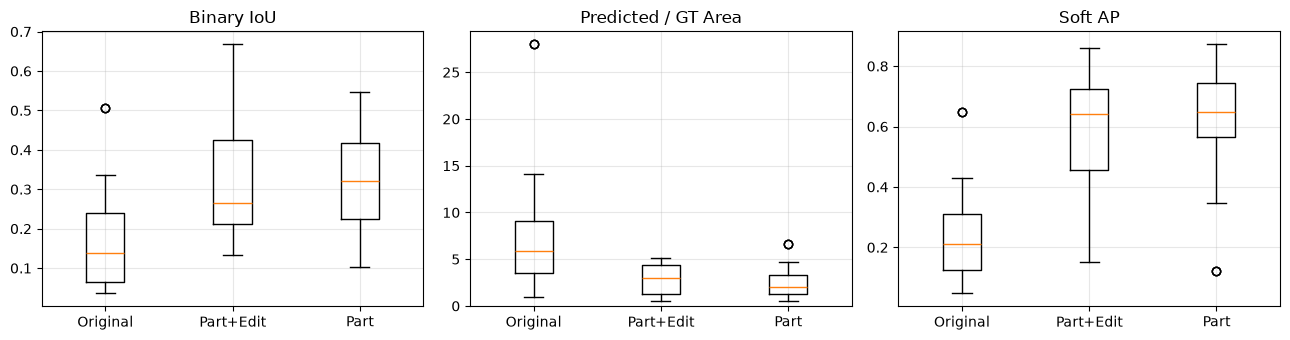

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
ordered_methods = ['original_fys', 'gated_part_edit', 'gated_part']
labels = [METHODS[m]['label'] for m in ordered_methods]
for ax, metric, title in [
    (axes[0], 'binary_iou', 'Binary IoU'),
    (axes[1], 'pred_to_gt_area_ratio', 'Predicted / GT Area'),
    (axes[2], 'soft_ap', 'Soft AP'),
]:
    data = [mask_metrics.loc[mask_metrics['method'] == m, metric].dropna().values for m in ordered_methods]
    ax.boxplot(data, tick_labels=['Original', 'Part+Edit', 'Part'])
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
axes[1].set_ylim(bottom=0)
fig.tight_layout()
chart_path = FIGURE_DIR / 'mask_metric_boxplots.png'
fig.savefig(chart_path, dpi=180, bbox_inches='tight')
chart_path


## 7. Image Preservation Metrics

These metrics compare each edited output with the source image. Outside-mask metrics use the complement of the GT part mask and measure whether non-target pixels are preserved. Inside-mask metrics measure how much the target part changed.

This section follows the same preservation metric standard as `03_evaluate_controlled_revision.ipynb`: outside/inside L1 auxiliary error, PSNR, masked global SSIM, and optional outside-mask LPIPS. LPIPS is computed only when `torch` and `lpips` are available, preferably on the GPU server. If LPIPS is unavailable locally, existing LPIPS values are preserved instead of being overwritten.


In [17]:
image_metrics_path = TABLE_DIR / 'image_preservation_metrics.csv'
existing_lpips = None
if image_metrics_path.exists():
    existing_image_metrics = pd.read_csv(image_metrics_path, dtype={'method': str, 'run_uid': str})
    if 'outside_mask_lpips' in existing_image_metrics.columns:
        existing_lpips = existing_image_metrics[['method', 'run_uid', 'outside_mask_lpips']].copy()
        existing_lpips['outside_mask_lpips'] = pd.to_numeric(existing_lpips['outside_mask_lpips'], errors='coerce')
        print('found existing LPIPS values:', existing_lpips['outside_mask_lpips'].notna().sum())

image_metric_rows = []
for _, row in runs.iterrows():
    source = load_rgb(row['source_image'])
    image_size = Image.open(repo_path(row['source_image'])).size
    edited = load_rgb(row['image_path'], size=image_size)
    gt_mask = load_mask(row['gt_mask'], size=image_size)
    outside_mask = ~gt_mask
    inside_mask = gt_mask
    outside_mse = masked_mse(source, edited, outside_mask)
    inside_mse = masked_mse(source, edited, inside_mask)
    image_metric_rows.append({
        'method': row['method'],
        'method_label': row['method_label'],
        'run_uid': row['run_uid'],
        'case_uid': row['case_uid'],
        'seed': row['seed'],
        'part_size': row['part_size'],
        'part': row['part'],
        'edit': row['edit'],
        'outside_mask_l1_aux': masked_l1(source, edited, outside_mask),
        'inside_mask_l1_aux': masked_l1(source, edited, inside_mask),
        'outside_mask_mse': outside_mse,
        'inside_mask_mse': inside_mse,
        'outside_mask_psnr': psnr_from_mse(outside_mse),
        'inside_mask_psnr': psnr_from_mse(inside_mse),
        'outside_mask_global_ssim': masked_global_ssim(source, edited, outside_mask),
        'inside_mask_global_ssim': masked_global_ssim(source, edited, inside_mask),
        'outside_mask_lpips': optional_outside_lpips(source, edited, gt_mask),
    })

image_metrics = pd.DataFrame(image_metric_rows)
if existing_lpips is not None:
    image_metrics = image_metrics.merge(existing_lpips, on=['method', 'run_uid'], how='left', suffixes=('', '_existing'))
    preserve_existing = image_metrics['outside_mask_lpips'].isna() & image_metrics['outside_mask_lpips_existing'].notna()
    image_metrics.loc[preserve_existing, 'outside_mask_lpips'] = image_metrics.loc[preserve_existing, 'outside_mask_lpips_existing']
    image_metrics = image_metrics.drop(columns=['outside_mask_lpips_existing'])
    print('preserved existing LPIPS values:', int(preserve_existing.sum()))

image_metrics.to_csv(image_metrics_path, index=False)
print('LPIPS non-empty after save:', image_metrics['outside_mask_lpips'].notna().sum())
image_summary = (
    image_metrics.groupby('method')
    .agg(
        runs=('run_uid', 'count'),
        outside_l1_aux=('outside_mask_l1_aux', 'mean'),
        outside_psnr=('outside_mask_psnr', 'mean'),
        outside_global_ssim=('outside_mask_global_ssim', 'mean'),
        outside_lpips=('outside_mask_lpips', 'mean'),
        inside_l1_aux=('inside_mask_l1_aux', 'mean'),
        inside_global_ssim=('inside_mask_global_ssim', 'mean'),
    )
    .reset_index()
)
image_summary


found existing LPIPS values: 0
preserved existing LPIPS values: 0
LPIPS non-empty after save: 0


,method,runs,outside_l1_aux,outside_psnr,outside_global_ssim,outside_lpips,inside_l1_aux,inside_global_ssim
0,gated_part,36,0.045971,22.104266,0.941098,NaN,0.112238,0.637705
1,gated_part_edit,36,0.046921,21.786454,0.938068,NaN,0.114147,0.634612
2,original_fys,36,0.055529,20.359764,0.919241,NaN,0.117014,0.614229


In [18]:
combined_summary = mask_summary.merge(image_summary, on=['method', 'runs'], how='outer')
combined_summary['method_label'] = combined_summary['method'].map({k: v['label'] for k, v in METHODS.items()})
combined_summary = combined_summary[[
    'method', 'method_label', 'runs', 'mean_iou', 'mean_soft_ap', 'mean_area_ratio',
    'outside_l1_aux', 'outside_psnr', 'outside_global_ssim', 'outside_lpips',
    'inside_l1_aux', 'inside_global_ssim'
]]
combined_summary.to_csv(TABLE_DIR / 'attention_gated_fys_summary.csv', index=False)
combined_summary


,method,method_label,runs,mean_iou,mean_soft_ap,mean_area_ratio,outside_l1_aux,outside_psnr,outside_global_ssim,outside_lpips,inside_l1_aux,inside_global_ssim
0,gated_part,Attention-Gated FYS (part-only),36,0.323419,0.619007,2.506237,0.045971,22.104266,0.941098,NaN,0.112238,0.637705
1,gated_part_edit,Attention-Gated FYS (part+edit),36,0.326501,0.591496,2.811809,0.046921,21.786454,0.938068,NaN,0.114147,0.634612
2,original_fys,Original FYS-TDM,36,0.173545,0.247025,8.042275,0.055529,20.359764,0.919241,NaN,0.117014,0.614229


## 8. Visual Comparison Sheet

The sheet below shows one seed per case. It is intended for visual diagnosis rather than publication formatting.


In [19]:
def to_uint8(image: np.ndarray) -> np.ndarray:
    return np.clip(image * 255, 0, 255).astype(np.uint8)


def overlay_mask(image: np.ndarray, mask: np.ndarray, color=(255, 0, 0), alpha=0.42) -> Image.Image:
    base = Image.fromarray(to_uint8(image)).convert('RGBA')
    overlay = Image.new('RGBA', base.size, (0, 0, 0, 0))
    color_image = Image.new('RGBA', base.size, (*color, 0))
    color_image.putalpha(Image.fromarray((mask.astype(np.float32) * 255 * alpha).clip(0, 255).astype(np.uint8)))
    return Image.alpha_composite(base, color_image).convert('RGB')


def heatmap_overlay(image: np.ndarray, score: np.ndarray, color=(255, 0, 255), alpha=0.42) -> Image.Image:
    score = normalize01(score)
    score_img = Image.fromarray((score * 255).astype(np.uint8)).resize(Image.fromarray(to_uint8(image)).size, Image.Resampling.BICUBIC)
    return overlay_mask(image, np.asarray(score_img).astype(np.float32) / 255.0, color=color, alpha=alpha)


def fit_text(text: str, width: int, font: ImageFont.ImageFont) -> list[str]:
    words = text.split()
    lines = []
    current = ''
    draw = ImageDraw.Draw(Image.new('RGB', (width, 10)))
    for word in words:
        candidate = f'{current} {word}'.strip()
        if draw.textbbox((0, 0), candidate, font=font)[2] <= width:
            current = candidate
        else:
            if current:
                lines.append(current)
            current = word
    if current:
        lines.append(current)
    return lines


def build_case_panel(case_uid: str, seed: int = 0, thumb=(135, 135), text_width=360) -> Image.Image:
    case = cases.loc[cases['case_uid'] == case_uid].iloc[0]
    source = load_rgb(case['source_image'])
    image_size = Image.open(repo_path(case['source_image'])).size
    gt_mask = load_mask(case['gt_mask'], size=image_size)
    source_image = Image.fromarray(to_uint8(source))

    method_images = []
    for method in ['original_fys', 'gated_part_edit', 'gated_part']:
        row = runs[(runs['case_uid'] == case_uid) & (runs['seed'] == seed) & (runs['method'] == method)].iloc[0]
        method_images.append(Image.fromarray(to_uint8(load_rgb(row['image_path'], size=image_size))))

    mask_panels = []
    for method, color in [('original_fys', (255, 0, 255)), ('gated_part_edit', (0, 170, 255)), ('gated_part', (255, 210, 0))]:
        row = runs[(runs['case_uid'] == case_uid) & (runs['seed'] == seed) & (runs['method'] == method)].iloc[0]
        score = load_array(row['mask_soft_path'])
        mask_panels.append(heatmap_overlay(source, score, color=color, alpha=0.45))

    panels = [
        source_image,
        overlay_mask(source, gt_mask, color=(255, 0, 0), alpha=0.45),
        *method_images,
        *mask_panels,
    ]
    labels = ['source', 'GT part', 'original FYS', 'gated part+edit', 'gated part', 'orig TDM', 'hybrid p+e', 'hybrid part']
    panels = [p.resize(thumb, Image.Resampling.BICUBIC) for p in panels]

    font = ImageFont.load_default()
    row_height = thumb[1] + 34
    canvas = Image.new('RGB', (text_width + len(panels) * thumb[0], row_height), 'white')
    draw = ImageDraw.Draw(canvas)
    metrics = mask_metrics[(mask_metrics['case_uid'] == case_uid) & (mask_metrics['seed'] == seed)]
    metric_text = ', '.join(
        f"{m.replace('gated_', 'g-')}:IoU={metrics.loc[metrics['method']==m, 'binary_iou'].iloc[0]:.2f}"
        for m in ['original_fys', 'gated_part_edit', 'gated_part']
    )
    text = (
        f"{case_uid} | {case['part_size']} | {case['part']} -> {case['edit']} | seed={seed}\n"
        f"{metric_text}\n"
        f"Target: {case['target_prompt']}"
    )
    y = 5
    for line in text.split('\n'):
        for wrapped in fit_text(line, text_width - 10, font):
            draw.text((6, y), wrapped, fill='black', font=font)
            y += 13
    x = text_width
    for label, panel in zip(labels, panels):
        draw.text((x + 4, 4), label, fill='black', font=font)
        canvas.paste(panel, (x, 20))
        x += thumb[0]
    return canvas

seed_for_sheet = 0
case_panels = [build_case_panel(case_uid, seed=seed_for_sheet) for case_uid in cases['case_uid']]
sheet_width = max(p.width for p in case_panels)
sheet_height = sum(p.height for p in case_panels)
sheet = Image.new('RGB', (sheet_width, sheet_height), 'white')
y = 0
for panel in case_panels:
    sheet.paste(panel, (0, y))
    y += panel.height
sheet_path = FIGURE_DIR / 'attention_gated_fys_case_sheet_seed0.jpg'
sheet.save(sheet_path, quality=95)
sheet_path


PosixPath('/Users/pt623/Documents/career-vault-resume/applications/hkust-harry-yang/part-level-overediting/core/results/attention_gated_fys_eval/figures/attention_gated_fys_case_sheet_seed0.jpg')

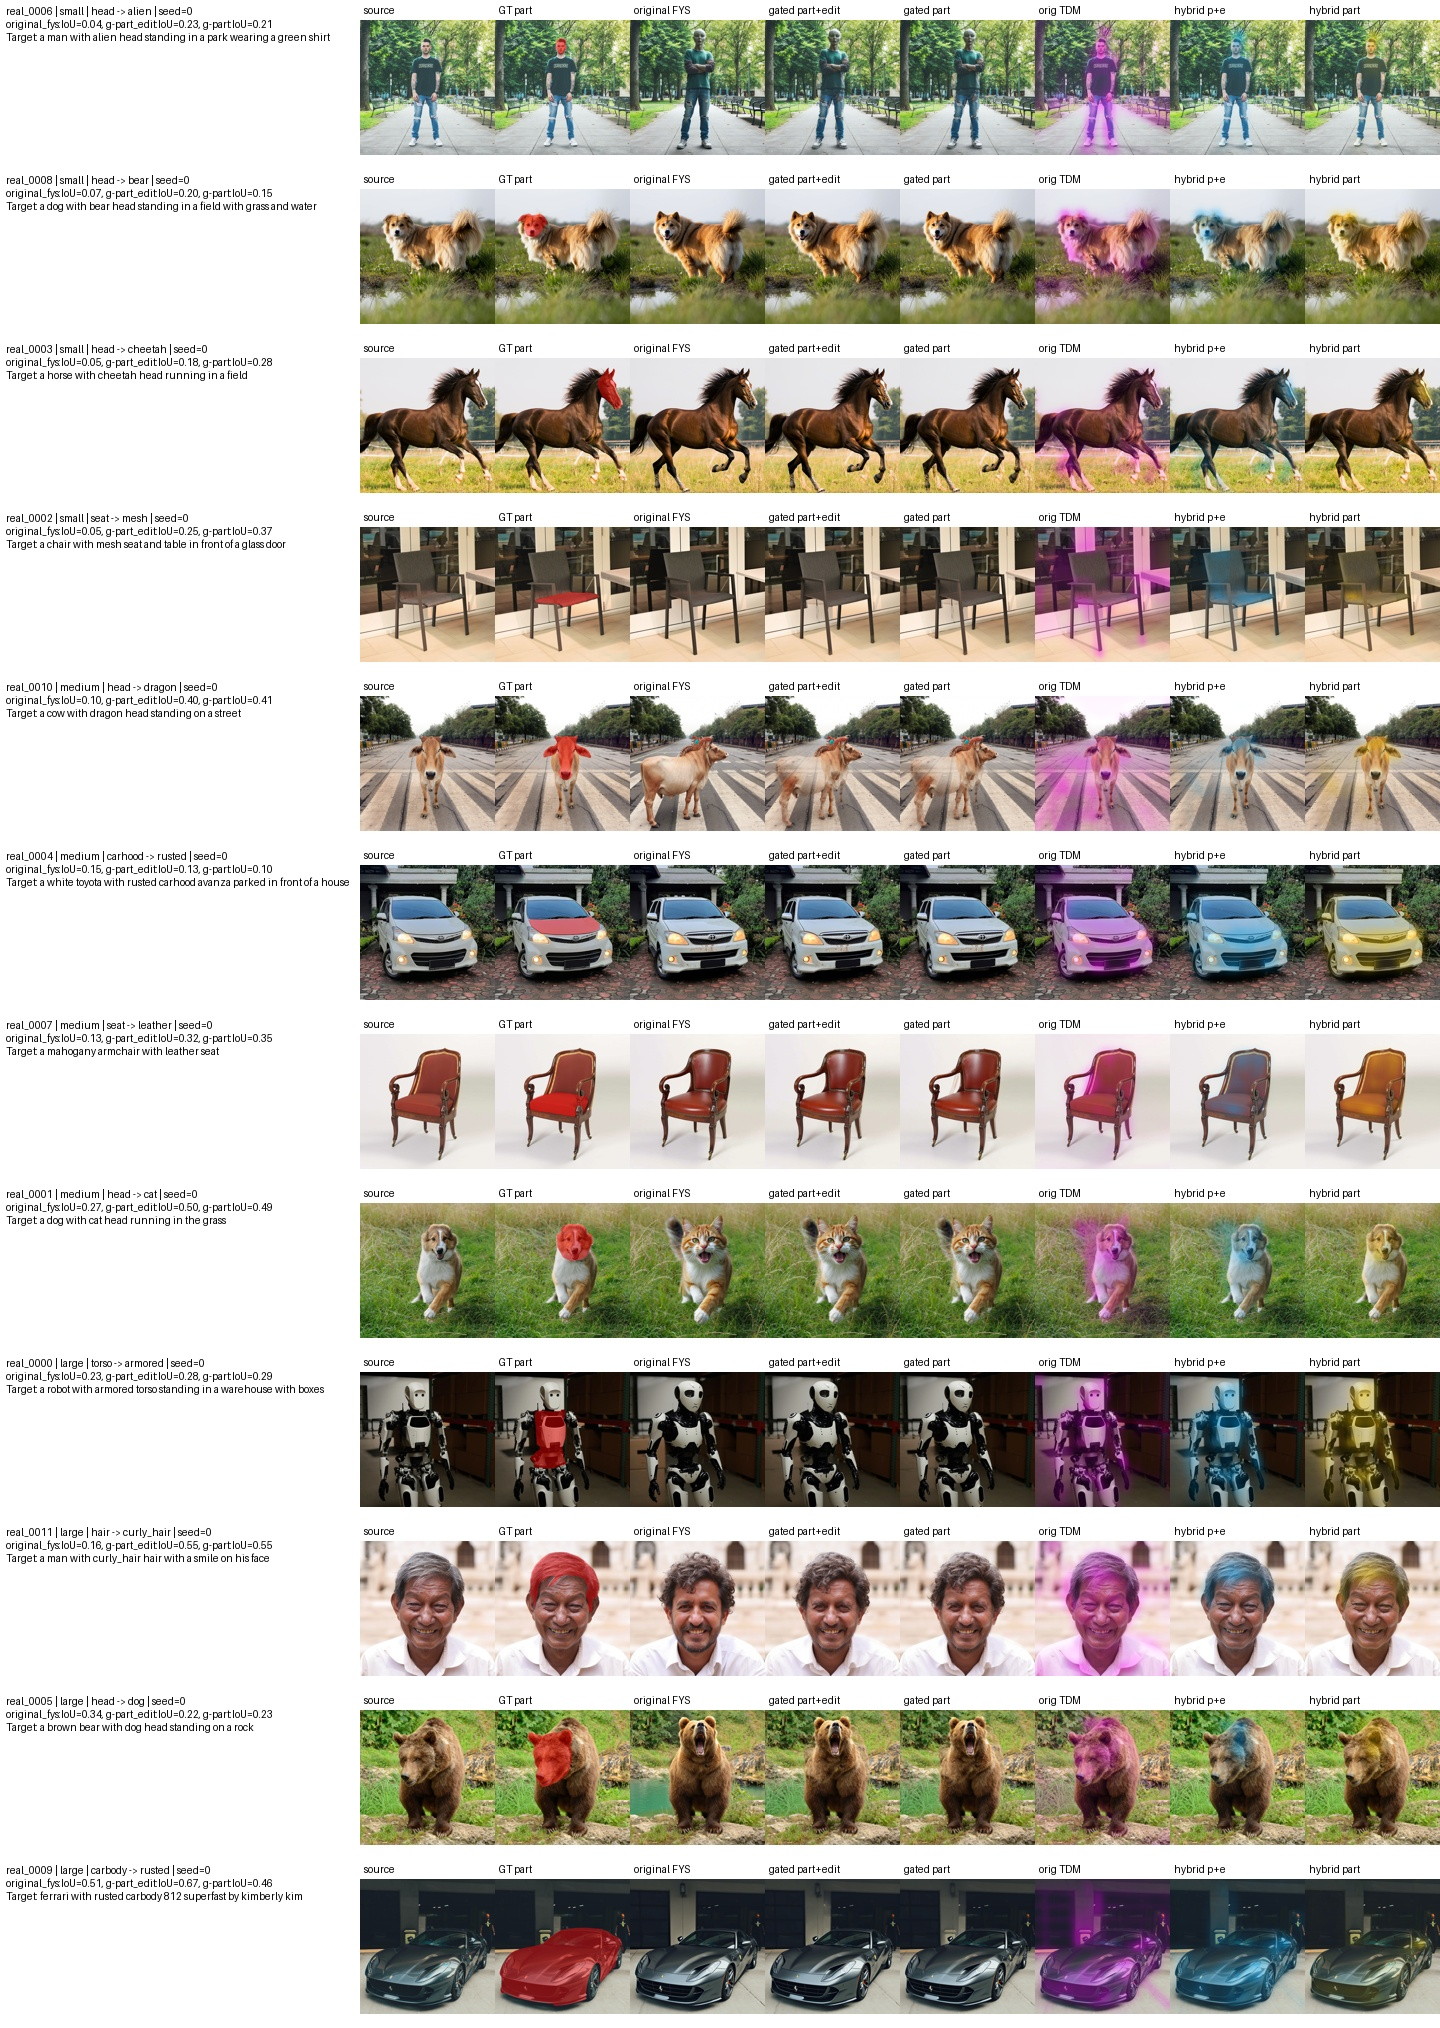

In [20]:
from IPython.display import display

display(Image.open(sheet_path))


## 10. Findings Draft

Observed findings from the current executed outputs:

- Attention-gated masks substantially improve localization compared with original FYS-TDM. Mean binary IoU improves from roughly `0.17` for original FYS to roughly `0.32` for both gated variants.
- Gating also reduces over-localization. Mean predicted/GT area ratio drops from roughly `8.0x` for original FYS to about `2.8x` for part+edit gating and `2.5x` for part-only gating.
- Part-only attention gives the most compact masks on average, while part+edit attention is slightly stronger on binary IoU. This suggests part tokens are useful as a spatial prior, while edit tokens can add object-level semantic spread.
- Better masks do not guarantee perfect part-level preservation. Outside-mask preservation improves modestly, but FYS remains a late, soft KV-control mechanism rather than a hard image-space mask.
- The seed commands are deterministic under the current FYS inversion path. Interpret the 36 command runs as 12 unique case outputs repeated across seeds for reproducibility, not as independent stochastic samples.

Main caveat: the oracle GT-mask ablation should not be mixed into this table yet because the current `--oracle-mask` path can be overwritten by the internally generated TDM `edit_map`. A clean oracle ablation requires a dedicated mode that sets the final Stage-3 `edit_map` directly from the GT mask.


In [21]:
base = mask_metrics[mask_metrics['method'] == 'original_fys'][['run_uid', 'binary_iou', 'pred_to_gt_area_ratio', 'soft_ap']].rename(columns={
    'binary_iou': 'original_iou',
    'pred_to_gt_area_ratio': 'original_area_ratio',
    'soft_ap': 'original_soft_ap',
})
deltas = mask_metrics[mask_metrics['method'].isin(['gated_part_edit', 'gated_part'])].merge(base, on='run_uid', how='left')
deltas['delta_iou'] = deltas['binary_iou'] - deltas['original_iou']
deltas['delta_area_ratio'] = deltas['pred_to_gt_area_ratio'] - deltas['original_area_ratio']
deltas['delta_soft_ap'] = deltas['soft_ap'] - deltas['original_soft_ap']
delta_summary = (
    deltas.groupby(['method', 'case_uid', 'part', 'edit', 'part_size'])
    .agg(
        mean_delta_iou=('delta_iou', 'mean'),
        mean_delta_area_ratio=('delta_area_ratio', 'mean'),
        mean_delta_soft_ap=('delta_soft_ap', 'mean'),
    )
    .reset_index()
    .sort_values(['method', 'mean_delta_iou'], ascending=[True, False])
)
delta_summary.to_csv(TABLE_DIR / 'attention_gated_fys_case_deltas.csv', index=False)
delta_summary


,method,case_uid,part,edit,part_size,mean_delta_iou,mean_delta_area_ratio,mean_delta_soft_ap
11,gated_part,real_0011,hair,curly_hair,large,0.383911,-4.072165,0.510874
2,gated_part,real_0002,seat,mesh,small,0.318604,-8.206897,0.564718
10,gated_part,real_0010,head,dragon,medium,0.306783,-7.148936,0.592225
3,gated_part,real_0003,head,cheetah,small,0.233429,-6.935484,0.507695
7,gated_part,real_0007,seat,leather,medium,0.222046,-1.250000,0.431092
1,gated_part,real_0001,head,cat,medium,0.218109,-1.932203,0.377283
6,gated_part,real_0006,head,alien,small,0.178571,-23.333333,0.514554
8,gated_part,real_0008,head,bear,small,0.079637,-7.500000,0.593498
0,gated_part,real_0000,torso,armored,large,0.062565,-1.072165,0.095528
4,gated_part,real_0004,carhood,rusted,medium,-0.044520,-2.529412,-0.161687


## 11. Output Files

This notebook writes analysis tables and figures under:

```text
core/results/attention_gated_fys_eval/
```

Main outputs:

```text
mask_localization_metrics.csv
image_preservation_metrics.csv
attention_gated_fys_summary.csv
attention_gated_fys_case_deltas.csv
figures/mask_metric_boxplots.png
figures/attention_gated_fys_case_sheet_seed0.jpg
```
